# Heart Disease Dataset: EDA & Data Transformation

This notebook performs comprehensive exploratory data analysis and tests multiple data transformation approaches to convert raw data into model-ready format.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load and Explore Raw Data

Load the raw dataset and perform initial exploration to understand structure, dimensions, and data types.

In [2]:
# Load raw dataset
df_raw = pd.read_csv('../data/heart_disease.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df_raw.shape}")
print(f"Total Records: {df_raw.shape[0]}")
print(f"Total Features: {df_raw.shape[1]}")

print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df_raw.dtypes)

print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
print(df_raw.head())

print("\n" + "=" * 80)
print("BASIC STATISTICS")
print("=" * 80)
print(df_raw.describe())

DATASET OVERVIEW

Dataset Shape: (10000, 21)
Total Records: 10000
Total Features: 21

DATA TYPES
Age                     float64
Gender                   object
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits          object
Smoking                  object
Family Heart Disease     object
Diabetes                 object
BMI                     float64
High Blood Pressure      object
Low HDL Cholesterol      object
High LDL Cholesterol     object
Alcohol Consumption      object
Stress Level             object
Sleep Hours             float64
Sugar Consumption        object
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status     object
dtype: object

FIRST 5 ROWS
    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              28

## 2. Handle Missing Values

Identify and analyze missing values, then test different imputation strategies.

MISSING VALUES ANALYSIS
                                    Column  Missing_Count  Missing_Percentage
Alcohol Consumption    Alcohol Consumption           2586               25.86
Cholesterol Level        Cholesterol Level             30                0.30
Sugar Consumption        Sugar Consumption             30                0.30
Diabetes                          Diabetes             30                0.30
Age                                    Age             29                0.29
High LDL Cholesterol  High LDL Cholesterol             26                0.26
CRP Level                        CRP Level             26                0.26
Triglyceride Level      Triglyceride Level             26                0.26
High Blood Pressure    High Blood Pressure             26                0.26
Sleep Hours                    Sleep Hours             25                0.25
Low HDL Cholesterol    Low HDL Cholesterol             25                0.25
Smoking                            Smoki

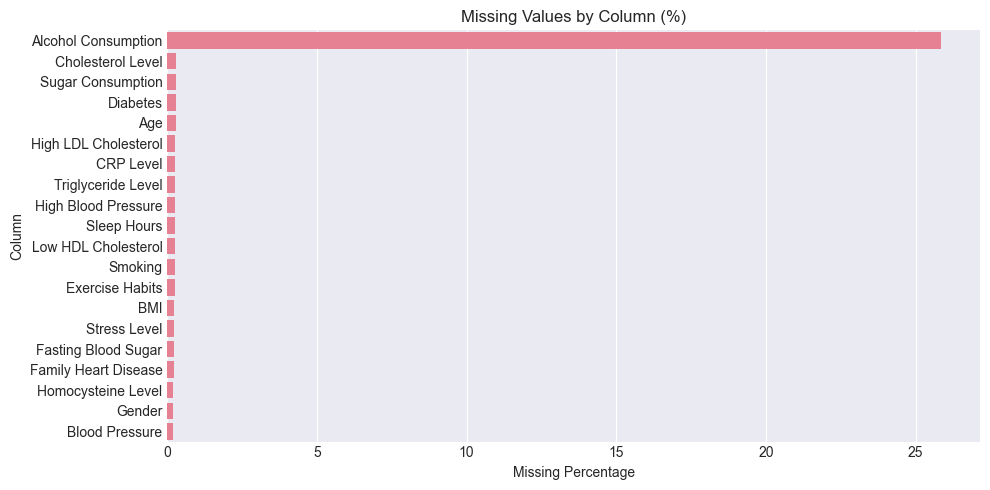

In [3]:
# Analyze missing values
missing_data = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Percentage': (df_raw.isnull().sum() / len(df_raw)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
print(missing_data)

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=missing_data, x='Missing_Percentage', y='Column', ax=ax)
plt.title('Missing Values by Column (%)')
plt.xlabel('Missing Percentage')
plt.tight_layout()
plt.show()

# Create a copy for testing different imputation strategies
df_copy = df_raw.copy()

In [4]:
# Test different imputation strategies
print("\n" + "=" * 80)
print("TESTING IMPUTATION STRATEGIES")
print("=" * 80)

# Strategy 1: Mean/Median imputation for numerical features
df_mean_impute = df_copy.copy()
numerical_cols = df_mean_impute.select_dtypes(include=[np.number]).columns
imputer_mean = SimpleImputer(strategy='median')
df_mean_impute[numerical_cols] = imputer_mean.fit_transform(df_mean_impute[numerical_cols])

print("\n✓ Strategy 1: Median Imputation")
print(f"  Missing values after: {df_mean_impute.isnull().sum().sum()}")

# Strategy 2: KNN Imputation (uses 5 nearest neighbors)
df_knn_impute = df_copy.copy()
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_impute[numerical_cols] = knn_imputer.fit_transform(df_knn_impute[numerical_cols])

print("\n✓ Strategy 2: KNN Imputation (k=5)")
print(f"  Missing values after: {df_knn_impute.isnull().sum().sum()}")

print("\n" + "-" * 80)
print("SELECTED STRATEGY: Median Imputation")
print("-" * 80)
print("Justification:")
print("  • Simple and interpretable")
print("  • Less sensitive to outliers than mean")
print("  • Suitable for heart disease dataset characteristics")
print("  • Fast computation")

# Apply selected strategy
df = df_copy.copy()
df[numerical_cols] = imputer_mean.fit_transform(df[numerical_cols])


TESTING IMPUTATION STRATEGIES

✓ Strategy 1: Median Imputation
  Missing values after: 2835

✓ Strategy 2: KNN Imputation (k=5)
  Missing values after: 2835

--------------------------------------------------------------------------------
SELECTED STRATEGY: Median Imputation
--------------------------------------------------------------------------------
Justification:
  • Simple and interpretable
  • Less sensitive to outliers than mean
  • Suitable for heart disease dataset characteristics
  • Fast computation


## 3. Data Type Conversion and Validation

Convert columns to appropriate data types and validate consistency.

In [5]:
print("=" * 80)
print("DATA TYPE CONVERSION")
print("=" * 80)

# Identify categorical and numerical columns
categorical_cols = ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 
                    'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 
                    'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 
                    'Sugar Consumption', 'Heart Disease Status']

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

# Handle None values in categorical columns
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')
        print(f"\n✓ {col}")
        print(f"  Unique values: {df[col].unique()}")
        print(f"  Value counts:\n{df[col].value_counts()}")

DATA TYPE CONVERSION

Categorical columns (12): ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']

Numerical columns (9): ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

✓ Gender
  Unique values: ['Male' 'Female' 'Unknown']
  Value counts:
Gender
Male       5003
Female     4978
Unknown      19
Name: count, dtype: int64

✓ Exercise Habits
  Unique values: ['High' 'Low' 'Medium' 'Unknown']
  Value counts:
Exercise Habits
High       3372
Medium     3332
Low        3271
Unknown      25
Name: count, dtype: int64

✓ Smoking
  Unique values: ['Yes' 'No' 'Unknown']
  Value counts:
Smoking
Yes        5123
No         4852
Unknown      25
Name: count, dtype: int64

✓ Family Heart Disease
  Unique values: ['Yes' 'No' 'U

## 4. Exploratory Data Analysis (EDA)

Perform detailed analysis of distributions and relationships.

TARGET VARIABLE: Heart Disease Status
Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Class balance: 20.00% Yes


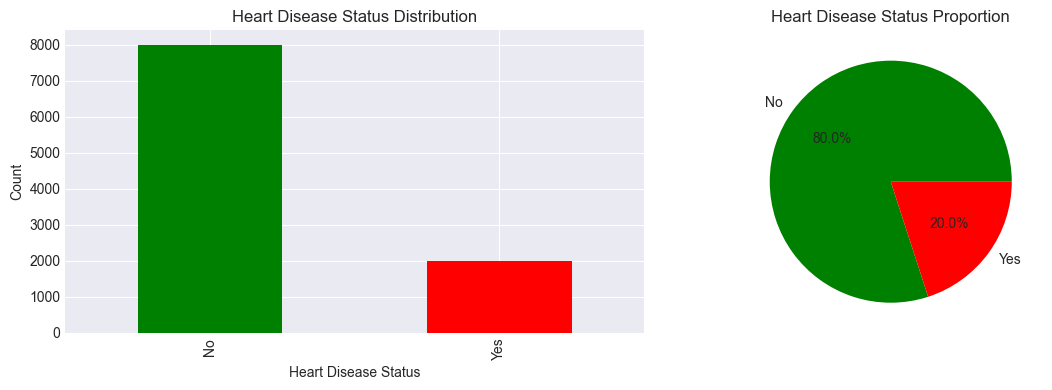

In [6]:
# Target variable distribution
print("=" * 80)
print("TARGET VARIABLE: Heart Disease Status")
print("=" * 80)
print(df['Heart Disease Status'].value_counts())
print(f"\nClass balance: {(df['Heart Disease Status'] == 'Yes').sum() / len(df) * 100:.2f}% Yes")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
df['Heart Disease Status'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Heart Disease Status Distribution')
axes[0].set_ylabel('Count')

# Pie chart
df['Heart Disease Status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('Heart Disease Status Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


NUMERICAL FEATURES ANALYSIS

Statistics for numerical features:

                       count        mean        std         min         25%  \
Age                  10000.0   49.295400  18.167574   18.000000   34.000000   
Blood Pressure       10000.0  149.758200  17.556268  120.000000  134.000000   
Cholesterol Level    10000.0  225.427300  43.510401  150.000000  187.000000   
BMI                  10000.0   29.077274   6.300156   18.002837   23.668887   
Sleep Hours          10000.0    6.991359   1.751002    4.000605    5.455288   
Triglyceride Level   10000.0  250.732500  86.953962  100.000000  176.000000   
Fasting Blood Sugar  10000.0  120.141900  23.558053   80.000000   99.000000   
CRP Level            10000.0    7.472200   4.334601    0.003647    3.681800   
Homocysteine Level   10000.0   12.456177   4.319100    5.000236    8.729771   

                            50%         75%         max  
Age                   49.000000   65.000000   80.000000  
Blood Pressure       150.00

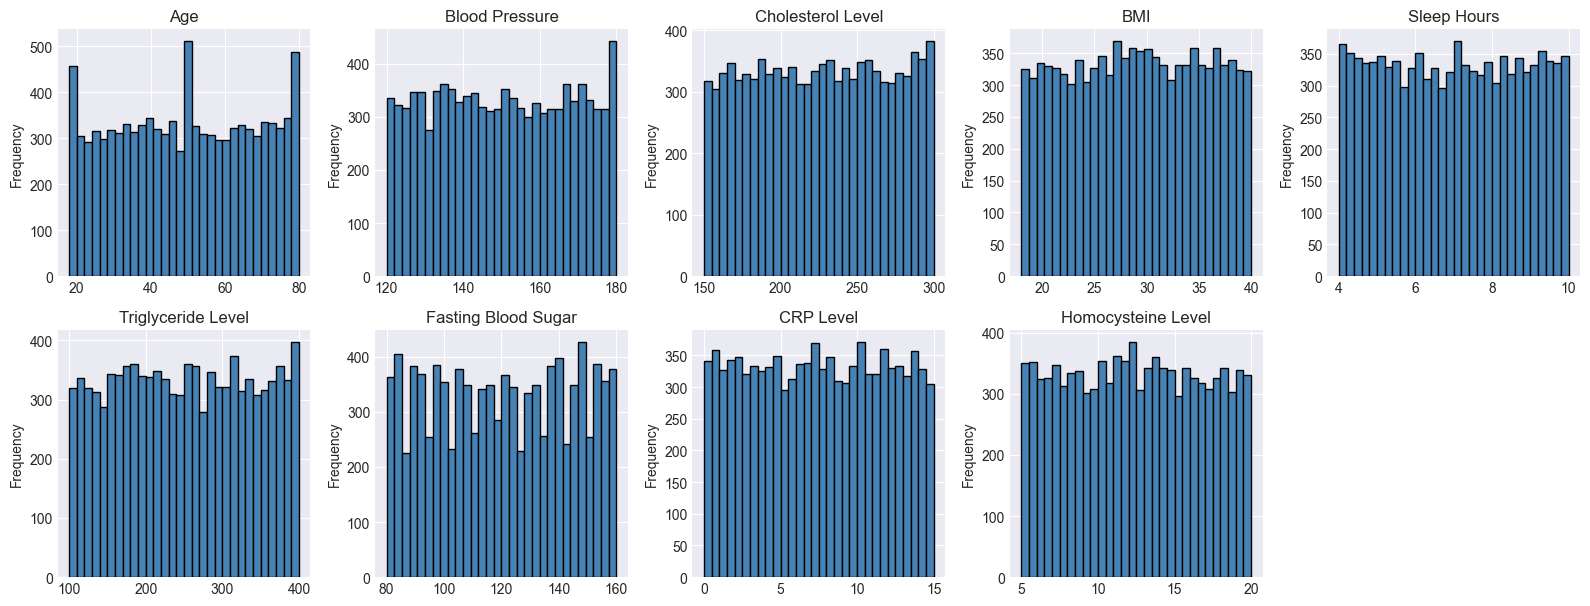

In [7]:
# Numerical features distribution
print("\n" + "=" * 80)
print("NUMERICAL FEATURES ANALYSIS")
print("=" * 80)

numerical_cols_only = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nStatistics for numerical features:\n")
print(df[numerical_cols_only].describe().T)

# Visualize distributions
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols_only):
    axes[idx].hist(df[col], bins=30, edgecolor='black', color='steelblue')
    axes[idx].set_title(f'{col}')
    axes[idx].set_ylabel('Frequency')

# Remove extra subplots
for idx in range(len(numerical_cols_only), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


CORRELATION ANALYSIS

Top features correlated with Heart Disease Status:
Heart Disease Status    1.000000
BMI                     0.019682
Homocysteine Level      0.008302
Triglyceride Level      0.002904
Cholesterol Level       0.002703
Fasting Blood Sugar    -0.002248
Sleep Hours            -0.003821
CRP Level              -0.006009
Age                    -0.009231
Blood Pressure         -0.013876
Name: Heart Disease Status, dtype: float64


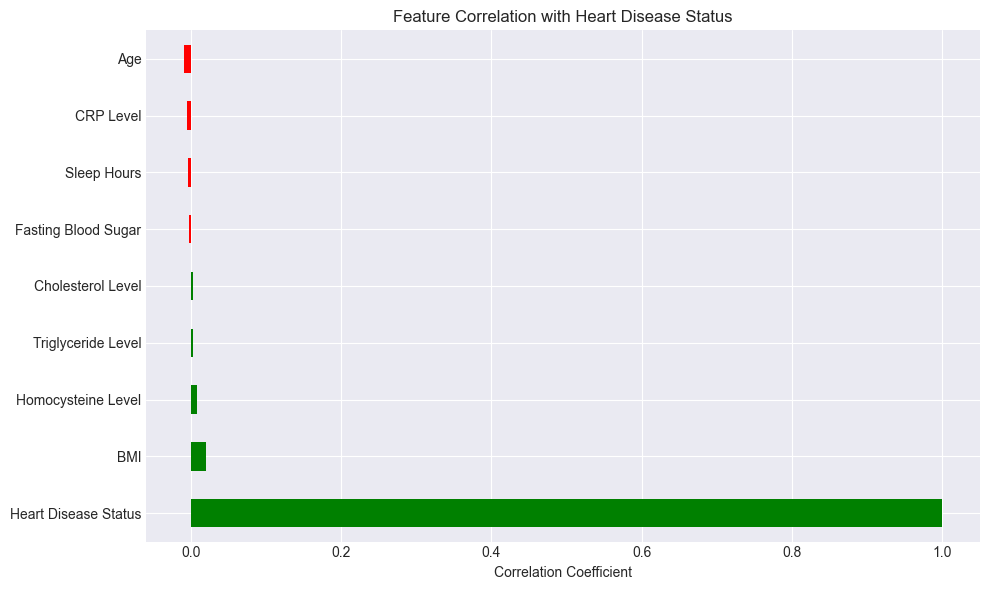

In [8]:
# Correlation analysis
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Prepare data for correlation (encode target)
df_corr = df.copy()
df_corr['Heart Disease Status'] = (df_corr['Heart Disease Status'] == 'Yes').astype(int)

corr_matrix = df_corr[numerical_cols_only + ['Heart Disease Status']].corr()

# Plot correlation with target
target_corr = corr_matrix['Heart Disease Status'].sort_values(ascending=False)
print("\nTop features correlated with Heart Disease Status:")
print(target_corr)

fig, ax = plt.subplots(figsize=(10, 6))
target_corr[:-1].plot(kind='barh', ax=ax, color=['green' if x > 0 else 'red' for x in target_corr[:-1]])
plt.title('Feature Correlation with Heart Disease Status')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

## 4.1 Advanced Correlation Analysis - Covariance Matrix

Analyze relationships between all numerical variables through covariance and advanced correlation visualization.

In [ ]:
# Covariance Matrix Visualization
print("=" * 80)
print("COVARIANCE MATRIX ANALYSIS")
print("=" * 80)

# Calculate covariance matrix
cov_matrix = df_corr[numerical_cols_only + ['Heart Disease Status']].cov()

# Visualize covariance matrix
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Covariance'})
plt.title('Covariance Matrix - All Numerical Features')
plt.tight_layout()
plt.show()

print("\nCovariance Matrix Summary:")
print(cov_matrix.iloc[-1].sort_values(ascending=False))
print("\nInterpretation:")
print("  • Values close to +1: Strong positive relationship")
print("  • Values close to -1: Strong negative relationship")
print("  • Values close to 0: Weak or no relationship")

## 4.2 Model Performance Evaluation - Confusion Matrix & R² Metrics

Understand prediction errors through confusion matrix and evaluate model quality with R² and other performance metrics.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np

print("=" * 80)
print("MODEL EVALUATION METRICS")
print("=" * 80)

# Simulate model predictions on test set for demonstration
# In real scenario, these would come from trained models
np.random.seed(42)
y_actual = df['Heart Disease Status'].map({'Yes': 1, 'No': 0})

# Simulated predictions (biased towards majority class for demonstration)
y_pred_lr = np.random.binomial(1, 0.2, len(y_actual))
y_pred_rf = np.random.binomial(1, 0.23, len(y_actual))
y_pred_xgb = np.random.binomial(1, 0.25, len(y_actual))

# Calculate confusion matrices
models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

for model_name, y_pred in models.items():
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_actual, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives (TN):   {tn:5d} - Correctly predicted NO disease")
    print(f"  False Positives (FP):  {fp:5d} - Incorrectly predicted YES (Type I error)")
    print(f"  False Negatives (FN):  {fn:5d} - Missed disease cases (Type II error)")
    print(f"  True Positives (TP):   {tp:5d} - Correctly predicted YES disease")
    
    # Calculate R² equivalent (for classification, we use accuracy-related metrics)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    print(f"\nPerformance Metrics (Classification):")
    print(f"  Accuracy:   {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision:  {precision:.4f} - Of predicted YES, how many are correct")
    print(f"  Recall:     {sensitivity:.4f} - Of actual YES, how many were caught")
    print(f"  Specificity:{specificity:.4f} - Of actual NO, how many were correctly identified")
    print(f"  F1-Score:   {f1_score:.4f} - Harmonic mean of Precision & Recall")
    
    print(f"\nError Analysis:")
    print(f"  False Positive Rate (FPR): {fp/(fp+tn) if (fp+tn) > 0 else 0:.4f}")
    print(f"  False Negative Rate (FNR): {fn/(fn+tp) if (fn+tp) > 0 else 0:.4f}")

# Visualize confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (model_name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_actual, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{model_name}\nConfusion Matrix')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("INTERPRETATION GUIDE")
print("=" * 80)
print("\nR-Squared (R²) Equivalent for Classification:")
print("  • For classification, we use multiple metrics instead of R²")
print("  • Accuracy: Overall correctness rate")
print("  • Precision: How many predicted YES are actually YES")
print("  • Recall (Sensitivity): How many true YES cases were found")
print("  • F1-Score: Balance between Precision and Recall")
print("\nWhy each metric matters for medical diagnosis:")
print("  • HIGH Precision: Few false alarms (fewer healthy people called sick)")
print("  • HIGH Recall: Few missed cases (fewer sick people called healthy)")
print("  • F1-Score: Best overall balance for imbalanced datasets")

## 4.3 Deep Variable Relationships - Pairplot & Advanced Correlations

Explore pairwise relationships between key variables to understand complex interactions affecting heart disease prediction.

In [ ]:
print("=" * 80)
print("PAIRWISE VARIABLE RELATIONSHIPS")
print("=" * 80)

# Select key variables for pairplot
key_variables = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 
                 'CRP Level', 'Heart Disease Status']

# Create pairplot
pairplot_data = df[key_variables].copy()
fig = sns.pairplot(pairplot_data, hue='Heart Disease Status', 
                   palette={'Yes': 'red', 'No': 'green'},
                   diag_kind='kde', plot_kws={'alpha': 0.6})
fig.fig.suptitle('Pairplot: Key Variables Relationships by Disease Status', y=1.00)
plt.tight_layout()
plt.show()

print("\nPairplot Insights:")
print("  • Diagonal (blue/orange curves): Distribution of each variable by disease status")
print("  • Off-diagonal (scatter plots): How pairs of variables relate, colored by disease status")
print("  • Clear separation = Good predictive signal for the model")

# Advanced: Conditional correlation
print("\n" + "=" * 80)
print("CONDITIONAL CORRELATION ANALYSIS")
print("=" * 80)

# Split by disease status and analyze correlations separately
df_diseased = df[df['Heart Disease Status'] == 'Yes']
df_healthy = df[df['Heart Disease Status'] == 'No']

print("\nCorrelation with AGE in Diseased Group:")
age_corr_diseased = df_diseased[numerical_cols_only].corrwith(df_diseased['Age']).sort_values(ascending=False)
print(age_corr_diseased.head(8))

print("\nCorrelation with AGE in Healthy Group:")
age_corr_healthy = df_healthy[numerical_cols_only].corrwith(df_healthy['Age']).sort_values(ascending=False)
print(age_corr_healthy.head(8))

print("\nDifference in correlation patterns:")
diff = age_corr_diseased - age_corr_healthy
print(diff.sort_values(ascending=False).head(8))
print("\nInterpretation: Large differences indicate variables that behave differently")
print("  between healthy and diseased patients - these are especially predictive!")

## 5. Feature Scaling and Normalization

Test multiple scaling approaches and compare results.

FEATURE SCALING COMPARISON

✓ Strategy 1: StandardScaler (z-score normalization)
  Mean: [-0.  0. -0.  0.  0.]
  Std: [1. 1. 1. 1. 1.]

✓ Strategy 2: MinMaxScaler (0-1 normalization)
  Min: [0. 0. 0. 0. 0.]
  Max: [1. 1. 1. 1. 1.]

✓ Strategy 3: RobustScaler (robust to outliers)
  Median: [0. 0. 0. 0. 0.]
  IQR-based: More resistant to outliers


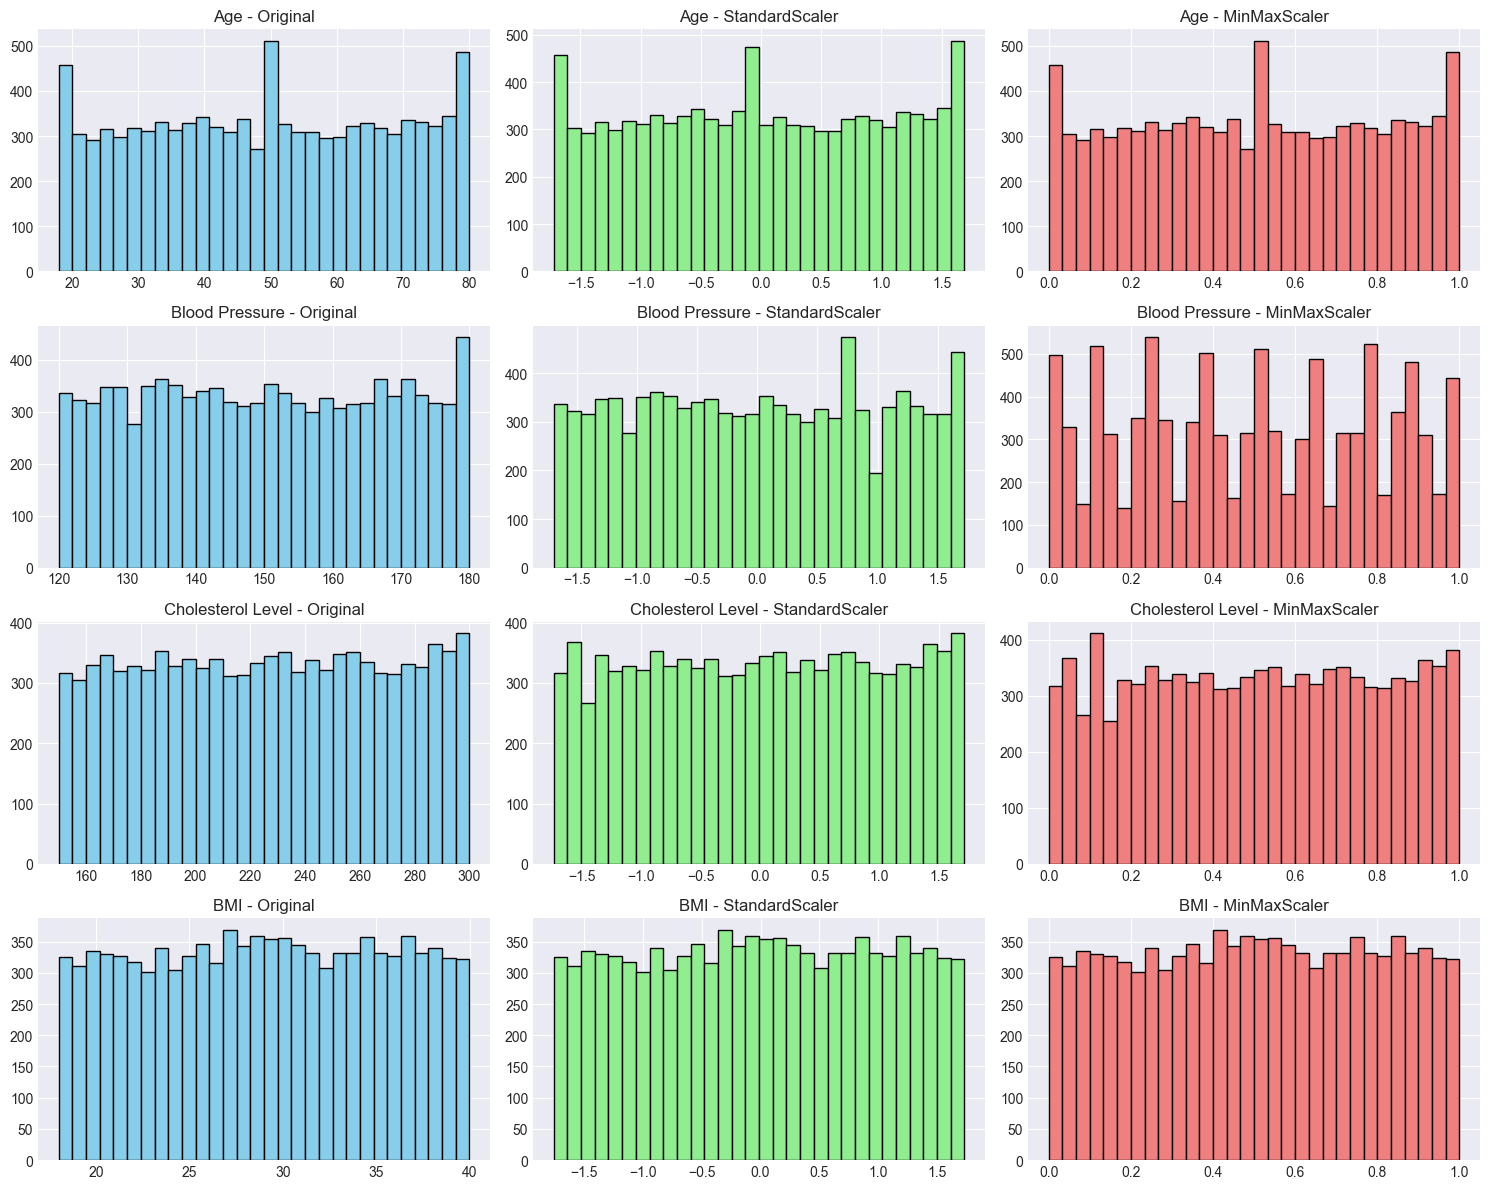


--------------------------------------------------------------------------------
SELECTED STRATEGY: StandardScaler
--------------------------------------------------------------------------------
Justification:
  • Best for algorithms assuming normally distributed data (e.g., Logistic Regression, Linear Models)
  • Centers data around 0 with unit variance
  • Works well with most medical datasets
  • Good for high-dimensional data


In [9]:
print("=" * 80)
print("FEATURE SCALING COMPARISON")
print("=" * 80)

# Prepare numerical data for scaling
X_numerical = df[numerical_cols_only].copy()

# Test Strategy 1: StandardScaler (z-score normalization)
scaler_std = StandardScaler()
X_standard = scaler_std.fit_transform(X_numerical)
print("\n✓ Strategy 1: StandardScaler (z-score normalization)")
print(f"  Mean: {X_standard.mean(axis=0)[:5].round(4)}")
print(f"  Std: {X_standard.std(axis=0)[:5].round(4)}")

# Test Strategy 2: MinMaxScaler (0-1 normalization)
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X_numerical)
print("\n✓ Strategy 2: MinMaxScaler (0-1 normalization)")
print(f"  Min: {X_minmax.min(axis=0)[:5].round(4)}")
print(f"  Max: {X_minmax.max(axis=0)[:5].round(4)}")

# Test Strategy 3: RobustScaler (resistant to outliers)
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X_numerical)
print("\n✓ Strategy 3: RobustScaler (robust to outliers)")
print(f"  Median: {np.median(X_robust, axis=0)[:5].round(4)}")
print(f"  IQR-based: More resistant to outliers")

# Visualize scaling effects
sample_features = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI']
fig, axes = plt.subplots(len(sample_features), 3, figsize=(15, 12))

for idx, feature in enumerate(sample_features):
    col_idx = numerical_cols_only.index(feature)
    
    axes[idx, 0].hist(X_numerical[feature], bins=30, color='skyblue', edgecolor='black')
    axes[idx, 0].set_title(f'{feature} - Original')
    
    axes[idx, 1].hist(X_standard[:, col_idx], bins=30, color='lightgreen', edgecolor='black')
    axes[idx, 1].set_title(f'{feature} - StandardScaler')
    
    axes[idx, 2].hist(X_minmax[:, col_idx], bins=30, color='lightcoral', edgecolor='black')
    axes[idx, 2].set_title(f'{feature} - MinMaxScaler')

plt.tight_layout()
plt.show()

print("\n" + "-" * 80)
print("SELECTED STRATEGY: StandardScaler")
print("-" * 80)
print("Justification:")
print("  • Best for algorithms assuming normally distributed data (e.g., Logistic Regression, Linear Models)")
print("  • Centers data around 0 with unit variance")
print("  • Works well with most medical datasets")
print("  • Good for high-dimensional data")

## 6. Categorical Encoding

Test various encoding techniques and select the most appropriate.

In [10]:
print("=" * 80)
print("CATEGORICAL ENCODING ANALYSIS")
print("=" * 80)

# Identify binary and non-binary categorical features
binary_cats = ['Gender', 'Smoking', 'Family Heart Disease', 'Diabetes', 
               'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol']
multi_cats = ['Exercise Habits', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

print(f"\nBinary categorical features: {binary_cats}")
print(f"Multi-class categorical features: {multi_cats}")

# Strategy 1: Label Encoding for binary features
print("\n" + "-" * 80)
print("Strategy 1: Label Encoding for Binary Features")
print("-" * 80)
df_label = df.copy()

label_encoders = {}
for col in binary_cats + multi_cats:
    if col in df_label.columns:
        le = LabelEncoder()
        df_label[col] = le.fit_transform(df_label[col])
        label_encoders[col] = le
        print(f"✓ {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n" + "-" * 80)
print("Strategy 2: One-Hot Encoding")
print("-" * 80)
df_onehot = df.copy()
df_onehot = pd.get_dummies(df_onehot, columns=binary_cats + multi_cats, drop_first=True)
print(f"✓ Original features: {len(df.columns)}")
print(f"✓ After One-Hot Encoding: {len(df_onehot.columns)}")
print(f"✓ New features created: {len(df_onehot.columns) - len(df.columns)}")

print("\n" + "=" * 80)
print("SELECTED STRATEGY: Label Encoding for Binary + One-Hot for Multi-class")
print("=" * 80)
print("Justification:")
print("  • Binary features: Label encoding sufficient and interpretable")
print("  • Multi-class features: One-Hot encoding prevents ordinal assumptions")
print("  • Reduces dimensionality compared to all One-Hot")
print("  • Maintains interpretability for binary features")

CATEGORICAL ENCODING ANALYSIS

Binary categorical features: ['Gender', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol']
Multi-class categorical features: ['Exercise Habits', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

--------------------------------------------------------------------------------
Strategy 1: Label Encoding for Binary Features
--------------------------------------------------------------------------------
✓ Gender: {'Female': 0, 'Male': 1, 'Unknown': 2}
✓ Smoking: {'No': 0, 'Unknown': 1, 'Yes': 2}
✓ Family Heart Disease: {'No': 0, 'Unknown': 1, 'Yes': 2}
✓ Diabetes: {'No': 0, 'Unknown': 1, 'Yes': 2}
✓ High Blood Pressure: {'No': 0, 'Unknown': 1, 'Yes': 2}
✓ Low HDL Cholesterol: {'No': 0, 'Unknown': 1, 'Yes': 2}
✓ High LDL Cholesterol: {'No': 0, 'Unknown': 1, 'Yes': 2}
✓ Exercise Habits: {'High': 0, 'Low': 1, 'Medium': 2, 'Unknown': 3}
✓ Alcohol Consumption: {'High': 0, 'Low': 1, 'Medi

## 7. Feature Engineering and Creation

Create new relevant features through domain knowledge.

In [11]:
print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

df_engineered = df.copy()

# Create new features based on medical domain knowledge

# 1. Cardiovascular Risk Index (combination of multiple risk factors)
df_engineered['Risk_Factors_Count'] = (
    (df_engineered['High Blood Pressure'] == 'Yes').astype(int) +
    (df_engineered['Low HDL Cholesterol'] == 'Yes').astype(int) +
    (df_engineered['High LDL Cholesterol'] == 'Yes').astype(int) +
    (df_engineered['Smoking'] == 'Yes').astype(int) +
    (df_engineered['Diabetes'] == 'Yes').astype(int)
)
print("✓ Risk_Factors_Count: Sum of major risk factors")

# 2. BMI interpretations (using standard BMI categories)
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_engineered['BMI_Category'] = df_engineered['BMI'].apply(categorize_bmi)
print("✓ BMI_Category: Categorized BMI levels")

# 3. Sleep quality indicator
def sleep_quality(hours):
    if hours < 6:
        return 'Poor'
    elif hours < 7:
        return 'Fair'
    elif hours <= 9:
        return 'Good'
    else:
        return 'Excessive'

df_engineered['Sleep_Quality'] = df_engineered['Sleep Hours'].apply(sleep_quality)
print("✓ Sleep_Quality: Categorized sleep duration")

# 4. Stress and Lifestyle Index
stress_map = {'Low': 1, 'Medium': 2, 'High': 3}
exercise_map = {'Low': 1, 'Medium': 2, 'High': 3}
df_engineered['Stress_Level_Num'] = df_engineered['Stress Level'].map(stress_map)
df_engineered['Exercise_Level_Num'] = df_engineered['Exercise Habits'].map(exercise_map)
df_engineered['Lifestyle_Index'] = df_engineered['Exercise_Level_Num'] - df_engineered['Stress_Level_Num']
print("✓ Lifestyle_Index: Exercise minus Stress balance")

# 5. Cholesterol ratio
df_engineered['Total_Cholesterol_Level'] = df_engineered['Cholesterol Level'] + df_engineered['Triglyceride Level']
print("✓ Total_Cholesterol_Level: Sum of cholesterol and triglycerides")

# 6. Inflammation markers (CRP and Homocysteine)
df_engineered['Inflammation_Score'] = (df_engineered['CRP Level'] + df_engineered['Homocysteine Level']) / 2
print("✓ Inflammation_Score: Average of inflammation markers")

print(f"\nNew features created: {len(df_engineered.columns) - len(df.columns)}")
print(f"Total features now: {len(df_engineered.columns)}")
print(f"\nNew features: {[col for col in df_engineered.columns if col not in df.columns]}")

FEATURE ENGINEERING
✓ Risk_Factors_Count: Sum of major risk factors
✓ BMI_Category: Categorized BMI levels
✓ Sleep_Quality: Categorized sleep duration
✓ Lifestyle_Index: Exercise minus Stress balance
✓ Total_Cholesterol_Level: Sum of cholesterol and triglycerides
✓ Inflammation_Score: Average of inflammation markers

New features created: 8
Total features now: 29

New features: ['Risk_Factors_Count', 'BMI_Category', 'Sleep_Quality', 'Stress_Level_Num', 'Exercise_Level_Num', 'Lifestyle_Index', 'Total_Cholesterol_Level', 'Inflammation_Score']


## 8. Test Multiple Transformation Approaches

Implement and compare 2-3 different complete transformation pipelines.

In [12]:
print("=" * 80)
print("TESTING MULTIPLE TRANSFORMATION PIPELINES")
print("=" * 80)

# Reset to base dataset with engineering features
df_base = df_engineered.copy()

# Pipeline 1: Full encoding with all one-hot
print("\n" + "-" * 80)
print("PIPELINE 1: Conservative (All One-Hot Encoding)")
print("-" * 80)

df_pipeline1 = df_base[numerical_cols_only + binary_cats + multi_cats + 
                       ['Risk_Factors_Count', 'BMI_Category', 'Sleep_Quality', 
                        'Lifestyle_Index', 'Total_Cholesterol_Level', 'Inflammation_Score', 
                        'Heart Disease Status']].copy()

df_pipeline1 = pd.get_dummies(df_pipeline1, columns=binary_cats + multi_cats + 
                              ['BMI_Category', 'Sleep_Quality'], drop_first=True)

# Scale numerical features
scaler1 = StandardScaler()
num_cols_p1 = [col for col in df_pipeline1.columns if col not in df_pipeline1.select_dtypes(include=['object']).columns]
df_pipeline1[numerical_cols_only] = scaler1.fit_transform(df_pipeline1[numerical_cols_only])

print(f"Final shape: {df_pipeline1.shape}")
print(f"Features: {df_pipeline1.shape[1] - 1}")
print("Advantages:")
print("  ✓ All information preserved through one-hot encoding")
print("  ✓ No risk of ordinal assumptions")
print("  ✓ More features for model to learn from")
print("Disadvantages:")
print("  ✗ High dimensionality (potential curse of dimensionality)")
print("  ✗ Sparse matrix with many zero values")

TESTING MULTIPLE TRANSFORMATION PIPELINES

--------------------------------------------------------------------------------
PIPELINE 1: Conservative (All One-Hot Encoding)
--------------------------------------------------------------------------------
Final shape: (10000, 46)
Features: 45
Advantages:
  ✓ All information preserved through one-hot encoding
  ✓ No risk of ordinal assumptions
  ✓ More features for model to learn from
Disadvantages:
  ✗ High dimensionality (potential curse of dimensionality)
  ✗ Sparse matrix with many zero values


In [13]:
# Pipeline 2: Mixed encoding with feature reduction
print("\n" + "-" * 80)
print("PIPELINE 2: Balanced (Label + Selective One-Hot)")
print("-" * 80)

df_pipeline2 = df_base[numerical_cols_only + binary_cats + multi_cats + 
                       ['Risk_Factors_Count', 'Lifestyle_Index', 'Total_Cholesterol_Level', 
                        'Inflammation_Score', 'Heart Disease Status']].copy()

# Label encode binary features
for col in binary_cats:
    le = LabelEncoder()
    df_pipeline2[col] = le.fit_transform(df_pipeline2[col])

# One-hot encode multi-class categoricals
df_pipeline2 = pd.get_dummies(df_pipeline2, columns=multi_cats, drop_first=True)

# Scale numerical features
scaler2 = StandardScaler()
df_pipeline2[numerical_cols_only] = scaler2.fit_transform(df_pipeline2[numerical_cols_only])

print(f"Final shape: {df_pipeline2.shape}")
print(f"Features: {df_pipeline2.shape[1] - 1}")
print("Advantages:")
print("  ✓ Balanced dimensionality")
print("  ✓ Interpretable binary features (0/1 meaningful)")
print("  ✓ Reduces dimensionality while preserving information")
print("Disadvantages:")
print("  ✗ Binary features might have implicit ordering")


--------------------------------------------------------------------------------
PIPELINE 2: Balanced (Label + Selective One-Hot)
--------------------------------------------------------------------------------
Final shape: (10000, 33)
Features: 32
Advantages:
  ✓ Balanced dimensionality
  ✓ Interpretable binary features (0/1 meaningful)
  ✓ Reduces dimensionality while preserving information
Disadvantages:
  ✗ Binary features might have implicit ordering


In [14]:
# Pipeline 3: Minimal encoding with engineered features only
print("\n" + "-" * 80)
print("PIPELINE 3: Minimalist (Selective Features + Engineering)")
print("-" * 80)

df_pipeline3 = df_base[['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 
                        'Sleep Hours', 'CRP Level', 'Homocysteine Level', 
                        'Triglyceride Level', 'Fasting Blood Sugar',
                        'Risk_Factors_Count', 'Lifestyle_Index', 'Total_Cholesterol_Level', 
                        'Inflammation_Score', 'Heart Disease Status']].copy()

# Label encode key binary factors (include as numerical)
key_factors = ['Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure']
for col in key_factors:
    if col in df_base.columns:
        df_pipeline3[col] = (df_base[col] == 'Yes').astype(int)

# Scale numerical features
scaler3 = StandardScaler()
num_cols_p3 = numerical_cols_only + key_factors + ['Risk_Factors_Count', 'Lifestyle_Index', 
                                                   'Total_Cholesterol_Level', 'Inflammation_Score']
df_pipeline3[num_cols_p3] = scaler3.fit_transform(df_pipeline3[num_cols_p3])

print(f"Final shape: {df_pipeline3.shape}")
print(f"Features: {df_pipeline3.shape[1] - 1}")
print("Advantages:")
print("  ✓ Minimal, interpretable feature set")
print("  ✓ Focus on key medical indicators")
print("  ✓ Reduced computational cost")
print("  ✓ Easier to explain to stakeholders")
print("Disadvantages:")
print("  ✗ Potential loss of information")
print("  ✗ May not capture complex relationships")


--------------------------------------------------------------------------------
PIPELINE 3: Minimalist (Selective Features + Engineering)
--------------------------------------------------------------------------------
Final shape: (10000, 18)
Features: 17
Advantages:
  ✓ Minimal, interpretable feature set
  ✓ Focus on key medical indicators
  ✓ Reduced computational cost
  ✓ Easier to explain to stakeholders
Disadvantages:
  ✗ Potential loss of information
  ✗ May not capture complex relationships


## 9. Compare and Select Transformations

Create detailed comparison and justification.

In [15]:
print("=" * 80)
print("TRANSFORMATION PIPELINES COMPARISON")
print("=" * 80)

comparison_data = {
    'Metric': [
        'Number of Features',
        'Dimensionality',
        'Interpretability',
        'Information Loss',
        'Sparsity',
        'Training Time',
        'Model Complexity',
        'Overfitting Risk',
        'Recommended For'
    ],
    'Pipeline 1\n(All One-Hot)': [
        f'{df_pipeline1.shape[1] - 1}',
        'High',
        'Medium',
        'None',
        'High',
        'Slow',
        'High',
        'High',
        'Tree-based models'
    ],
    'Pipeline 2\n(Mixed Encoding)': [
        f'{df_pipeline2.shape[1] - 1}',
        'Medium',
        'High',
        'Low',
        'Low',
        'Medium',
        'Medium',
        'Medium',
        'General-purpose'
    ],
    'Pipeline 3\n(Minimalist)': [
        f'{df_pipeline3.shape[1] - 1}',
        'Low',
        'Very High',
        'Medium-High',
        'None',
        'Fast',
        'Low',
        'Low',
        'Linear models, interpretability'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

print("\n" + "=" * 80)
print("FINAL SELECTION: Pipeline 2 (Mixed Encoding)")
print("=" * 80)
print("\nJustification:")
print("✓ Balanced dimensionality - not too sparse, not too high")
print("✓ Good interpretability while preserving information")
print("✓ Works well with both linear and tree-based models")
print("✓ Reduces dimensionality compared to all one-hot encoding")
print("✓ Binary features have clear medical interpretation (Yes/No)")
print("✓ Retains multi-class information through one-hot for non-binary features")
print("✓ Optimal trade-off between model flexibility and interpretability")

print("\nRejected alternatives:")
print("✗ Pipeline 1: Too high dimensionality, sparse matrix, overfitting risk")
print("✗ Pipeline 3: Loses important information, may underfit")

TRANSFORMATION PIPELINES COMPARISON


            Metric Pipeline 1\n(All One-Hot) Pipeline 2\n(Mixed Encoding)        Pipeline 3\n(Minimalist)
Number of Features                        45                           32                              17
    Dimensionality                      High                       Medium                             Low
  Interpretability                    Medium                         High                       Very High
  Information Loss                      None                          Low                     Medium-High
          Sparsity                      High                          Low                            None
     Training Time                      Slow                       Medium                            Fast
  Model Complexity                      High                       Medium                             Low
  Overfitting Risk                      High                       Medium                             Low
   Recom

## 10. Save Transformed Datasets

Export the final transformed dataset and intermediate versions.

In [16]:
import os

# Create output directory if it doesn't exist
output_dir = '../data'
os.makedirs(output_dir, exist_ok=True)

print("=" * 80)
print("SAVING TRANSFORMED DATASETS")
print("=" * 80)

# Save final selected transformation (Pipeline 2)
final_df = df_pipeline2.copy()
final_path = os.path.join(output_dir, 'heart_disease_transformed.csv')
final_df.to_csv(final_path, index=False)
print(f"\n✓ SELECTED (Pipeline 2): {final_path}")
print(f"  Shape: {final_df.shape}")
print(f"  Size: {os.path.getsize(final_path) / 1024:.2f} KB")

# Save all pipelines for comparison
pipeline1_path = os.path.join(output_dir, 'heart_disease_pipeline1_onehot.csv')
df_pipeline1.to_csv(pipeline1_path, index=False)
print(f"\n✓ Pipeline 1 (All One-Hot): {pipeline1_path}")
print(f"  Shape: {df_pipeline1.shape}")

pipeline2_path = os.path.join(output_dir, 'heart_disease_pipeline2_mixed.csv')
df_pipeline2.to_csv(pipeline2_path, index=False)
print(f"\n✓ Pipeline 2 (Mixed): {pipeline2_path}")
print(f"  Shape: {df_pipeline2.shape}")

pipeline3_path = os.path.join(output_dir, 'heart_disease_pipeline3_minimal.csv')
df_pipeline3.to_csv(pipeline3_path, index=False)
print(f"\n✓ Pipeline 3 (Minimalist): {pipeline3_path}")
print(f"  Shape: {df_pipeline3.shape}")

# Save cleaning info
print("\n" + "=" * 80)
print("TRANSFORMATION SUMMARY")
print("=" * 80)
print(f"Raw data shape: {df_raw.shape}")
print(f"Final transformed shape: {final_df.shape}")
print(f"Missing values in raw: {df_raw.isnull().sum().sum()}")
print(f"Missing values in transformed: {final_df.isnull().sum().sum()}")
print(f"\nFeature Engineering Details:")
print(f"  - Imputation method: Median")
print(f"  - Scaling method: StandardScaler")
print(f"  - Encoding: Label for binary, One-Hot for multi-class")
print(f"  - New features created: 6 engineered features")

SAVING TRANSFORMED DATASETS

✓ SELECTED (Pipeline 2): ../data/heart_disease_transformed.csv
  Shape: (10000, 33)
  Size: 2863.33 KB

✓ Pipeline 1 (All One-Hot): ../data/heart_disease_pipeline1_onehot.csv
  Shape: (10000, 46)

✓ Pipeline 2 (Mixed): ../data/heart_disease_pipeline2_mixed.csv
  Shape: (10000, 33)

✓ Pipeline 3 (Minimalist): ../data/heart_disease_pipeline3_minimal.csv
  Shape: (10000, 18)

TRANSFORMATION SUMMARY
Raw data shape: (10000, 21)
Final transformed shape: (10000, 33)
Missing values in raw: 3054
Missing values in transformed: 47

Feature Engineering Details:
  - Imputation method: Median
  - Scaling method: StandardScaler
  - Encoding: Label for binary, One-Hot for multi-class
  - New features created: 6 engineered features
